In [187]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

DATA COLLECTION AND PREPARATION

In [188]:
!pip install kagglehub --quiet

import os
import kagglehub
import pandas as pd

path = kagglehub.dataset_download("imakash3011/customer-personality-analysis")

files = os.listdir(path)
print("Files in dataset:", files)  # so you can see what's there

# Load the first CSV file found
csv_files = [f for f in files if f.endswith('.csv')]
df = pd.read_csv(os.path.join(path, "marketing_campaign.csv"), sep='\t')

print(f"Dataset loaded successfully: {df.shape}")
df.head()

Using Colab cache for faster access to the 'customer-personality-analysis' dataset.
Files in dataset: ['marketing_campaign.csv']
Dataset loaded successfully: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [189]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [190]:
df.dtypes

,0
ID,int64
Year_Birth,int64
Education,object
Marital_Status,object
Income,float64
Kidhome,int64
Teenhome,int64
Dt_Customer,object
Recency,int64
MntWines,int64


In [191]:
df = df.drop(["ID"], axis=1)
df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,...,7,0,0,0,0,0,0,3,11,1
1,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,...,5,0,0,0,0,0,0,3,11,0
2,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,...,4,0,0,0,0,0,0,3,11,0
3,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,...,6,0,0,0,0,0,0,3,11,0
4,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,...,5,0,0,0,0,0,0,3,11,0


In [192]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

In [193]:
df.isnull().sum()

,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0
MntFruits,0


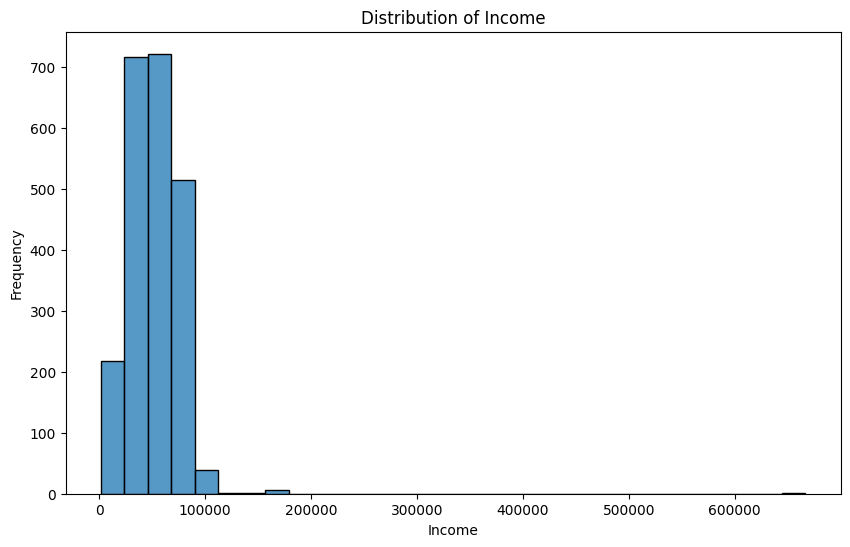

In [194]:
plt.figure(figsize=(10,6))
sns.histplot(df["Income"], bins=30)
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.title("Distribution of Income")
plt.show()

Income is skewed , so we fill missing values with median.

In [195]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [196]:
df.isnull().sum()

,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0
MntFruits,0


In [197]:
df.duplicated().sum()

np.int64(182)

In [198]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [199]:
df.dtypes

,0
Year_Birth,int64
Education,object
Marital_Status,object
Income,float64
Kidhome,int64
Teenhome,int64
Dt_Customer,datetime64[ns]
Recency,int64
MntWines,int64
MntFruits,int64


In [200]:
oe = OrdinalEncoder(categories=[["Basic", "2n Cycle", "Graduation", "Master", "PhD"]])
df["Education"] = oe.fit_transform(df[["Education"]])

Concerning Marital Status, it will not be useful because the clusters are separating almost entirely on Marital Status which means your one-hot encoded marital status columns are dominating the distance calculations.

In [201]:
df = df.drop(["Marital_Status"], axis=1)

In [202]:

df.columns


Index(['Year_Birth', 'Education', 'Income', 'Kidhome', 'Teenhome',
       'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

FEATURE ENGINEERING

In [203]:
df['Age'] = 2024 - df['Year_Birth']

In [204]:
reference_date = df['Dt_Customer'].max()
df['Customer_Tenure'] = (reference_date - df['Dt_Customer']).dt.days
df.drop(columns=['Year_Birth', 'Dt_Customer'], inplace=True)

In [205]:
df = df.drop(["Z_CostContact", "Z_Revenue"], axis=1)

In [206]:
X = df
X.head()

,Education,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Customer_Tenure
0,2.0,58138.0,0,0,58,635,88,546,172,88,...,7,0,0,0,0,0,0,1,67,663
1,2.0,46344.0,1,1,38,11,1,6,2,1,...,5,0,0,0,0,0,0,0,70,113
2,2.0,71613.0,0,0,26,426,49,127,111,21,...,4,0,0,0,0,0,0,0,59,312
3,2.0,26646.0,1,0,26,11,4,20,10,3,...,6,0,0,0,0,0,0,0,40,139
4,4.0,58293.0,1,0,94,173,43,118,46,27,...,5,0,0,0,0,0,0,0,43,161


In [207]:
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

In [208]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

Elbow Method

In [209]:
inertias = []
k_range = range(2,11)

for k in k_range:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(X_scaled)
  inertias.append(kmeans.inertia_)
  print(f"K={k}, Inertias= {kmeans.inertia_:.2f}")

K=2, Inertias= 41120.84
K=3, Inertias= 37748.20
K=4, Inertias= 35414.81
K=5, Inertias= 33953.83
K=6, Inertias= 31595.95
K=7, Inertias= 30973.64
K=8, Inertias= 29633.60
K=9, Inertias= 28243.35
K=10, Inertias= 27290.20


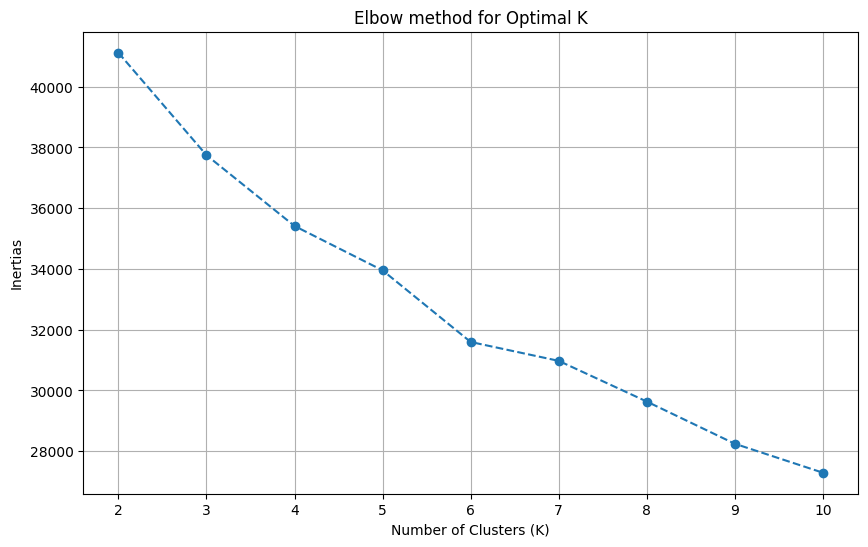

In [210]:
plt.figure(figsize=(10,6))
plt.plot(k_range, inertias, marker="o", linestyle="--")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertias")
plt.title("Elbow method for Optimal K")
plt.grid()
plt.show()

In [211]:
#Silhouette score
from sklearn.metrics import silhouette_score
silhouette_scores = []
k_range = range(2,11)

for k in k_range:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  cluster_labels = kmeans.fit_predict(X_scaled)

  silhouette_avg = silhouette_score(X_scaled, cluster_labels)
  silhouette_scores.append(silhouette_avg)
  print(f"K = {k} : Silhouette Score = {silhouette_avg}")

K = 2 : Silhouette Score = 0.2384152101138487
K = 3 : Silhouette Score = 0.16670209002755806
K = 4 : Silhouette Score = 0.16709912006510227
K = 5 : Silhouette Score = 0.1694146456043653
K = 6 : Silhouette Score = 0.17760275828288025
K = 7 : Silhouette Score = 0.10949580091151567
K = 8 : Silhouette Score = 0.11133895515216616
K = 9 : Silhouette Score = 0.11256389607361146
K = 10 : Silhouette Score = 0.11914041763498595


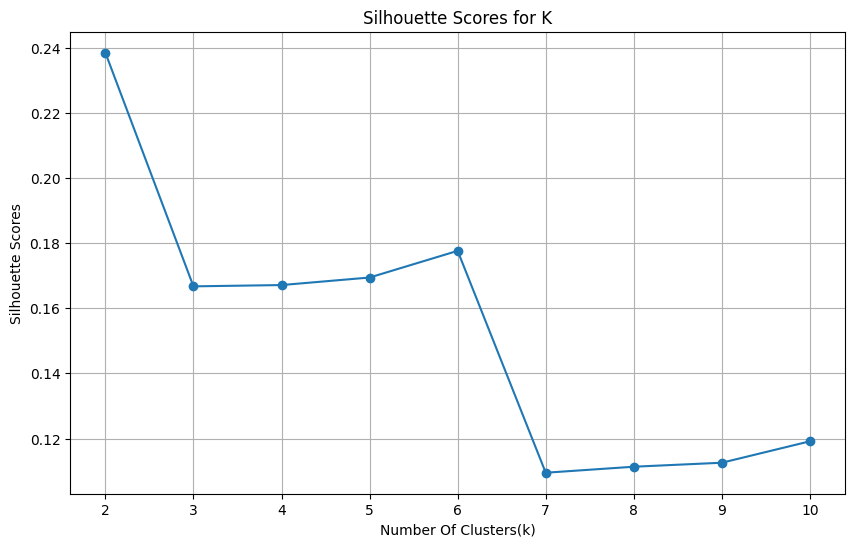

In [212]:
plt.figure(figsize=(10,6))
plt.plot(k_range, silhouette_scores, marker="o", linestyle="-")
plt.xlabel("Number Of Clusters(k)")
plt.ylabel("Silhouette Scores")
plt.title("Silhouette Scores for K")
plt.grid(True)
plt.show()

My elbow method suggested that k=4 while silhouette score got k=2. But we would use k=4 to get actionable business insights.


In [213]:
# Building final KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

In [214]:
df["kmeans_clusters"] = kmeans_labels
df["kmeans_clusters"].value_counts()

,count
kmeans_clusters,
2,929
1,555
0,419
3,155


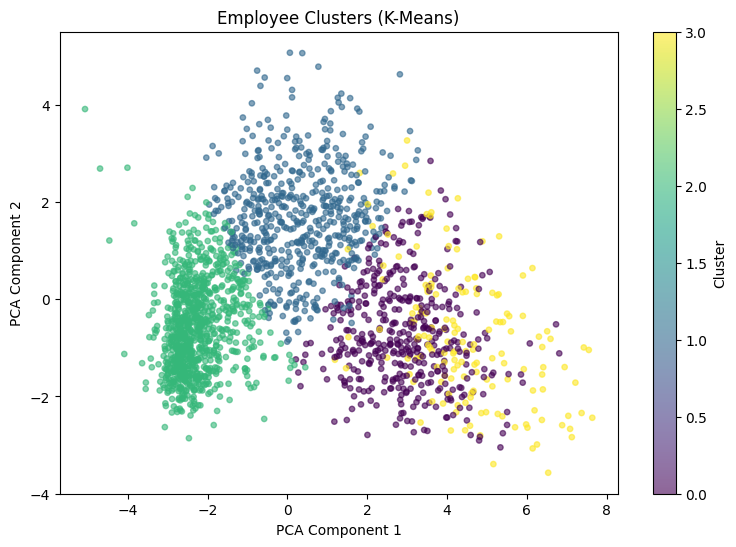

In [215]:
plt.figure(figsize=(9, 6))
plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=kmeans_labels, cmap="viridis", alpha=0.6, s=15
)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Employee Clusters (K-Means)")
plt.colorbar(label="Cluster")
plt.show()

In [216]:
print(df.groupby('kmeans_clusters').mean().round(2))

                 Education    Income  Kidhome  Teenhome  Recency  MntWines  \
kmeans_clusters                                                              
0                     2.38  74030.38     0.05      0.24    49.07    488.10   
1                     2.72  56956.42     0.23      0.95    48.18    449.23   
2                     2.32  34897.76     0.81      0.43    49.30     39.59   
3                     2.61  81802.24     0.05      0.14    49.32    870.01   

                 MntFruits  MntMeatProducts  MntFishProducts  \
kmeans_clusters                                                
0                    71.32           430.91           104.61   
1                    19.45           125.81            26.62   
2                     4.91            23.12             6.91   
3                    56.45           472.80            76.13   

                 MntSweetProducts  ...  NumWebVisitsMonth  AcceptedCmp3  \
kmeans_clusters                    ...                                 

Cluster 0 - "Comfortable Spenders"
High income, high spending across all categories, few children, low web visits, older customers. Prefer offline channels.

Cluster 1 — "Settled Mid-Tier"
Medium income, moderate spending, mostly has teenagers at home, highly active on web, oldest group. Digitally engaged but moderate buyers.

Cluster 2 — "Budget Conscious"
Lowest income, lowest spending across all categories, most children at home, youngest group, highest web visits but barely accepts any campaigns.

Cluster 3 — "Premium Loyalists"
Highest income, highest spending on wine and meat, most campaign-responsive group by far, few children. The most valuable customer segment.